# Delivery-Time Prediction: Simple Averaging and Constrained MAE Stacking

This study extends the four existing model families with two retained ensembles: a **50/50 average of Ridge and random-forest predictions**, and **constrained MAE stacking with weights learned from historical out-of-fold (OOF) predictions**. Simple averaging provides a reference without learned combination weights; strictly speaking, it is not stacking.

The central question is whether learning combination weights provides enough improvement to justify the additional complexity. Across seven historical validation months, constrained stacking achieved a mean monthly MAE of **5.724 days**, compared with **5.717 days** for the 50/50 average. These results do not establish a clear advantage for learned weights. Other ensemble attempts are retained only as compact appendix tables.

**Evaluation boundary: the original final-test results had already been inspected before this exploratory development.** This release reproduces historical monthly validation for two fixed methods. It neither generates nor scores predictions for the test period beginning in July, and it does not establish an improvement on a new independent test set.

By default, this notebook reads the published aggregate results and can run without private artifacts. Order-level data, OOF predictions, individual predictions, and fitted models are not uploaded to the repository.


In [1]:
from pathlib import Path
import hashlib
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents]
             if (path / "src/delivery_regression.py").is_file()), None)
if ROOT is None and (Path.cwd() / "Phase 2/Regression/historical_temporal/src/delivery_regression.py").is_file():
    ROOT = Path.cwd() / "Phase 2/Regression/historical_temporal"
if ROOT is None:
    raise FileNotFoundError("Run from the repository root, Phase 2/Regression/historical_temporal, or its notebooks directory.")
sys.path.insert(0, str(ROOT / "src"))
DEST = ROOT / "versions/ensemble_comparison"

# Read published summaries by default. A full rerun requires the original course CSVs
# and explicitly replaces the local outputs for this experiment.
RUN_EXPERIMENT = False
CSV_DIR = None  # Example: Path("/path/to/Olist_CSV"). Do not commit personal paths.
if RUN_EXPERIMENT:
    if CSV_DIR is None:
        raise ValueError("Set CSV_DIR before enabling RUN_EXPERIMENT.")
    subprocess.run([sys.executable, str(ROOT / "scripts/reproduce_ensemble_comparison.py"),
                    "--csv-dir", str(CSV_DIR), "--overwrite"], cwd=ROOT, check=True)

def table(name):
    return pd.read_csv(DEST / "outputs/tables" / name)

def read_json(name):
    return json.loads((DEST / "outputs" / name).read_text())

required = ["main_summary.csv", "monthly_metrics.csv", "coverage_by_month.csv",
            "final_weights.csv", "initial_model_comparison.csv", "other_attempts.csv",
            "prior_test_comparison.csv"]
missing = [name for name in required if not (DEST / "outputs/tables" / name).exists()]
if missing:
    raise FileNotFoundError("Missing published summaries: " + ", ".join(missing))
protocol = read_json("experiment_protocol.json")
result = read_json("run_result.json")
assert result["test_scored"] is False
assert result["test_predictions_generated"] is False
summary, monthly = table("main_summary.csv"), table("monthly_metrics.csv")
METHODS = ["linear", "ridge", "tree", "forest", "mean_ridge_forest", "convex_two_full_history"]
LABELS = {"linear": "Linear regression", "ridge": "Reviewed Ridge", "tree": "Decision tree",
          "forest": "Recency-weighted random forest", "mean_ridge_forest": "Ridge + forest: 50/50 average",
          "convex_two_full_history": "Ridge + forest: constrained MAE stack"}
print("Published results directory:", DEST.relative_to(ROOT))
print("Test predictions generated in this run:", result["test_predictions_generated"])
print("Test set scored in this run:", result["test_scored"])


Published results directory: versions/ensemble_comparison
Test predictions generated in this run: False
Test set scored in this run: False


## 1. Starting from Four Model Families

The existing models are linear regression, Ridge regression, a decision tree, and a random forest. This experiment reuses the features and model configurations established in the preceding review; it does not search the base-model hyperparameters again.

| Model | Version used in the monthly comparison | Relationship to the initial configuration |
|---|---|---|
| Linear regression | `linear` | Original version retained |
| Ridge | `ridge_logx_a1000` | Log-transformed selected numeric inputs and alpha=1000; initial Ridge used alpha=100 |
| Decision tree | `tree_d8` | Depth-8 version retained |
| Random forest | `rf_recent180` | Recency-weighted version with a 180-day weight half-life; training is not restricted to the latest 180 days |

Accordingly, references to Ridge and forest below mean the **reviewed variants**, not the original parameter settings. The following table preserves the historical March validation results as the starting point. Its single-month scores should not be compared directly with the seven-month averages reported later.


In [2]:
print("Historical single-model comparison: respect the evaluation period; do not compare directly with seven-month averages.")
initial = table("initial_model_comparison.csv")
display(initial[["model_label", "configuration", "n", "MAE_days", "RMSE_days", "period"]]
        .rename(columns={"model_label": "Model", "configuration": "Configuration", "n": "Orders",
                         "MAE_days": "MAE (days)", "RMSE_days": "RMSE (days)", "period": "Evaluation period"}).round(4))


Historical single-model comparison: respect the evaluation period; do not compare directly with seven-month averages.


,Model,Configuration,Orders,MAE (days),RMSE (days),Evaluation period
0,Linear regression,LinearRegression,7003,6.9180,10.6739,March 2018 validation; audited geography v2
1,Initial Ridge,alpha=100,7003,6.9134,10.6633,March 2018 validation; audited geography v2
2,Decision tree,max_depth=8; min_samples_leaf=20,7003,7.2364,11.2050,March 2018 validation; audited geography v2
3,Initial random forest,max_depth=24; min_samples_leaf=10,7003,7.0106,10.8404,March 2018 validation; audited geography v2
4,Reviewed Ridge,7 numeric inputs log1p; alpha=1000,7003,6.8475,10.5835,March 2018 validation; audited geography v2
5,Reviewed random forest,180-day exponential recency half-life,7003,6.9129,10.6818,March 2018 validation; audited geography v2


## 2. Temporal Validation and Label Availability

The target is the continuous number of days from purchase to delivery. At each monthly forecast origin $t$, base models train only on orders with **purchase time < $t$ and delivery time < $t$**. Preprocessing is fitted within that training set. Monthly historical forecasts provide OOF predictions. Meta-model fitting additionally requires the OOF forecast origin to precede the current $t$, preventing the use of current-month or future labels.

| Period | Purpose |
|---|---|
| July-September 2017 | Accumulate OOF predictions for meta-model warm-up |
| October 2017-April 2018 | Seven primary validation months; report the equally weighted mean of monthly MAE |
| May 2018 | Sensitivity check after the design was frozen; excluded from the original selection |
| June 2018 | Not scored; OOF labels already observable may contribute to the final pre-July historical fit |

All targets included in historical scoring must also have been delivered **before 2018-07-01**. Approximately 27.44% of eligible June orders still lacked observable labels at that cutoff, so June is not treated as a complete validation month. The coverage denominator consists of eventually identifiable eligible orders in the data, not all platform orders. Unobserved labels are not assigned zero error. The evaluation assumes monthly retraining and does not directly represent a model held fixed for two months.


In [3]:
coverage = table("coverage_by_month.csv")
display(coverage[["month", "role", "eligible_n", "known_by_july_n", "pending_n", "pending_pct"]]
        .rename(columns={"role": "Purpose", "eligible_n": "Eligible orders", "known_by_july_n": "Labels visible before July",
                         "pending_n": "Labels still unavailable", "pending_pct": "Unavailable (%)"}).round(3))


,month,Purpose,Eligible orders,Labels visible before July,Labels still unavailable,Unavailable (%)
0,2017-07,warmup,3872,3872,0,0.000
1,2017-08,warmup,4193,4193,0,0.000
2,2017-09,warmup,4150,4150,0,0.000
3,2017-10,primary,4478,4478,0,0.000
4,2017-11,primary,7288,7288,0,0.000
5,2017-12,primary,5513,5513,0,0.000
6,2018-01,primary,7069,7068,1,0.014
7,2018-02,primary,6555,6552,3,0.046
8,2018-03,primary,7003,7003,0,0.000
9,2018-04,primary,6798,6793,5,0.074


## 3. Two Retained Ensemble Methods

**Method A: 50/50 simple average.** Average the two nonnegative base predictions, expressed in days, without fitting a meta-model:

$$\hat y_{\mathrm{mean}}=0.5\hat y_{\mathrm{Ridge}}+0.5\hat y_{\mathrm{Forest}}.$$

**Method B: constrained MAE stacking.** Learn combination weights from all historical OOF rows satisfying the label-availability rules before the forecast origin:

$$\min_{w_R,w_F}\frac{1}{n}\sum_{i=1}^{n}\left|y_i-w_R\hat y_{i,R}-w_F\hat y_{i,F}\right|,
\qquad w_R,w_F\geq0,\quad w_R+w_F=1,\quad b=0.$$

The implementation uses linear programming to optimize absolute error directly. Weights act on predictions in their original day scale, and the intercept is fixed at zero. The combined prediction lies between the two base predictions. The weights can adjust the mixture, but these constraints cannot guarantee correction when both base models err in the same direction.

The functions below show the implementation used in the experiment; the full reproduction script uses the same `ConvexMAERegressor`. The default notebook displays saved results without training. Final weights come from the historical fit at 2018-07-01. Each validation month fits its own weights; final weights must not be applied retrospectively to replace those monthly fits.


In [4]:
from stacking_tuning import ConvexMAERegressor, meta_fit_rows

META_COLUMNS = ["ridge_oof_days", "forest_oof_days"]

def predict_equal_average(base_predictions):
    """Base predictions must be aligned by order_id and expressed in days."""
    return base_predictions[META_COLUMNS].mean(axis=1).to_numpy()

def fit_constrained_stacking(historical_oof, origin):
    """Apply strict time and label filters to all eligible history, with no extra window."""
    fit = meta_fit_rows(historical_oof, pd.Timestamp(origin), window_days=None, gap_days=0)
    model = ConvexMAERegressor().fit(fit[META_COLUMNS], fit["lead_time_days"])
    assert np.all(model.coef_ >= 0) and np.isclose(model.coef_.sum(), 1)
    assert model.intercept_ == 0
    return model

weights = table("final_weights.csv")
display(weights[["candidate", "input", "weight_in_days_space", "intercept_days", "weight_sum"]]
        .replace({"candidate": LABELS}).round(5))
print("These are final historical-fit weights. Relearn them when retraining; they are not permanent fixed proportions.")


,candidate,input,weight_in_days_space,intercept_days,weight_sum
0,Ridge + forest: constrained MAE stack,ridge_oof_days,0.53098,0.0,1.0
1,Ridge + forest: constrained MAE stack,forest_oof_days,0.46902,0.0,1.0
2,Ridge + forest: 50/50 average,ridge_oof_days,0.50000,0.0,1.0
3,Ridge + forest: 50/50 average,forest_oof_days,0.50000,0.0,1.0


These are final historical-fit weights. Relearn them when retraining; they are not permanent fixed proportions.


## 4. Comparison on the Same Months and Orders

The primary metric is the **equally weighted mean of MAE across seven months**, measured in days; lower is better. Worst-month MAE, mean monthly RMSE, and mean absolute monthly bias describe additional trade-offs. `bias = prediction - actual`; negative values indicate underprediction.

The following table compares the four retained base models and two ensembles over the same evaluation windows. May is reported separately and does not enter the primary metric. Months with more observations do not receive greater weight in that metric.


In [5]:
main = summary.loc[summary["candidate"].isin(METHODS)].copy()
primary = main.loc[main.role.eq("primary")].set_index("candidate").loc[METHODS]
sensitivity = main.loc[main.role.eq("sensitivity")].set_index("candidate").loc[METHODS]
comparison = primary[["MAE_month_mean", "MAE_worst_month", "RMSE_month_mean", "bias_abs_month_mean"]].copy()
comparison["May_MAE_days"] = sensitivity["MAE_month_mean"]
comparison.index = comparison.index.map(LABELS)
comparison = comparison.rename(columns={"MAE_month_mean": "Primary mean MAE", "MAE_worst_month": "Worst-month MAE",
    "RMSE_month_mean": "Mean monthly RMSE", "bias_abs_month_mean": "Mean absolute monthly bias", "May_MAE_days": "May MAE"})
display(comparison.round(4))

learned = primary.loc["convex_two_full_history", "MAE_month_mean"]
equal = primary.loc["mean_ridge_forest", "MAE_month_mean"]
forest = primary.loc["forest", "MAE_month_mean"]
print(f"MAE reduction of constrained stacking relative to the forest: {100 * (forest - learned) / forest:.2f}%")
print(f"Constrained stacking minus 50/50 average: {learned - equal:+.6f} days; positive values favor simple averaging.")
print("This difference is a historical validation point estimate, not a statistical significance or equivalence test.")


,Primary mean MAE,Worst-month MAE,Mean monthly RMSE,Mean absolute monthly bias,May MAE
candidate,,,,,
Linear regression,6.3985,8.2385,9.7909,4.5252,4.4565
Reviewed Ridge,5.7739,6.9677,9.1466,2.8624,4.6045
Decision tree,5.9191,7.2364,9.3905,2.9342,4.7592
Recency-weighted random forest,5.7473,6.9488,9.1565,2.9233,4.7553
Ridge + forest: 50/50 average,5.7172,6.9234,9.1093,2.8929,4.5740
Ridge + forest: constrained MAE stack,5.7237,6.9227,9.1217,2.9289,4.5929


MAE reduction of constrained stacking relative to the forest: 0.41%
Constrained stacking minus 50/50 average: +0.006498 days; positive values favor simple averaging.
This difference is a historical validation point estimate, not a statistical significance or equivalence test.


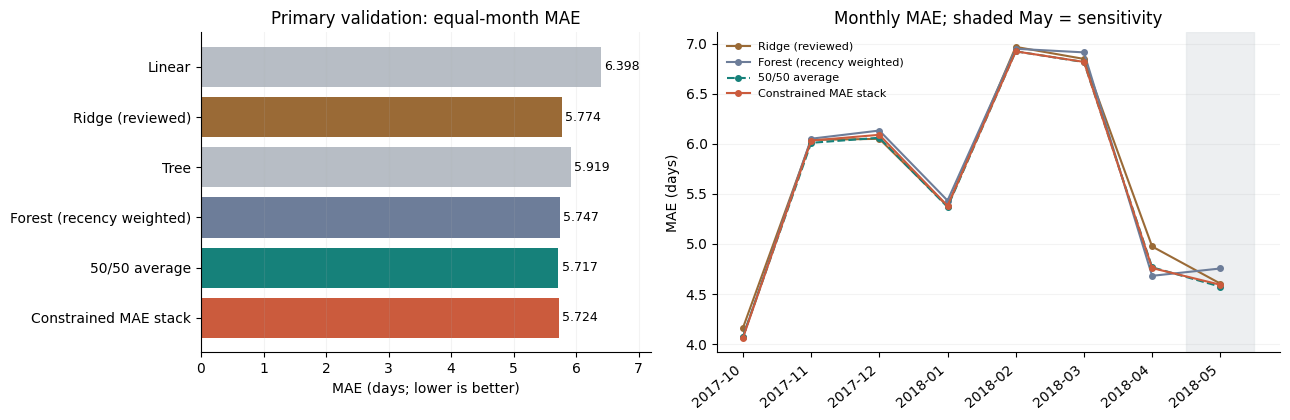

In [6]:
# Plot the primary aggregate and monthly sensitivity comparison.
plot_names = {"linear": "Linear", "ridge": "Ridge (reviewed)", "tree": "Tree",
              "forest": "Forest (recency weighted)", "mean_ridge_forest": "50/50 average",
              "convex_two_full_history": "Constrained MAE stack"}
colors = {"ridge": "#9A6A36", "forest": "#6D7D99", "mean_ridge_forest": "#16817A",
          "convex_two_full_history": "#CB5B3D"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1, 1.25]})
values = primary.loc[METHODS, "MAE_month_mean"]
axes[0].barh([plot_names[x] for x in METHODS], values,
             color=[colors.get(x, "#B7BDC5") for x in METHODS])
axes[0].invert_yaxis()
axes[0].set_xlim(0, float(values.max()) + .8)
for row, value in enumerate(values):
    axes[0].text(value + .05, row, f"{value:.3f}", va="center", fontsize=9)
axes[0].set_title("Primary validation: equal-month MAE")
axes[0].set_xlabel("MAE (days; lower is better)")
months = sorted(monthly["month"].unique())
for method in ["ridge", "forest", "mean_ridge_forest", "convex_two_full_history"]:
    curve = monthly.loc[monthly.candidate.eq(method)].set_index("month").loc[months]
    axes[1].plot(np.arange(len(months)), curve.MAE_days, marker="o", markersize=4,
                 label=plot_names[method], color=colors[method],
                 linestyle="--" if method == "mean_ridge_forest" else "-")
axes[1].axvspan(len(months)-1.5, len(months)-.5, color="#DFE3E7", alpha=.55)
axes[1].set_xticks(np.arange(len(months)), months, rotation=40, ha="right")
axes[1].set_title("Monthly MAE; shaded May = sensitivity")
axes[1].set_ylabel("MAE (days)")
axes[1].legend(fontsize=8, frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x" if ax is axes[0] else "y", alpha=.15)
fig.tight_layout()
plt.show()
plt.close(fig)


## 5. Conclusions and Limitations

Constrained stacking reduced primary validation MAE by approximately **0.41%** relative to the recency-weighted forest, but did not outperform the 50/50 average. Its final learned weights were also close to equal proportions. The evidence supports retaining simple averaging as a low-complexity ensemble reference and constrained stacking as a documented experiment in learning weights. **It does not establish a clear, consistent additional benefit from stacking.**

May is a sensitivity check only. Linear regression outperformed both ensembles in that month, so the ensembles were not uniformly best across months. An improvement in mean performance does not imply improvements in every month or every error metric.

Limitations include previously selected base configurations without nested validation, reuse of the primary months during earlier tuning, development decisions informed by the already observed original test results, and conditioning on completed deliveries with finite label maturity. New future data that have not influenced development are required to assess independent generalization gains.


## Appendix A. Summary of Other Attempts

Earlier attempts included a four-model Ridge meta-model, four-model constrained MAE stacking, median regression, a 180-day meta-training window, and a 30-day purchase-time gap. The table preserves their results and selection rationale; this publication entry point does not rerun the complete search. The earlier two-stage procedure used equal-month MAE over the seven primary months. Candidates within 0.01 days of the minimum were chosen according to a predefined simplicity preference, retaining the two-model constrained combination with all eligible history. The 0.01-day tolerance is an operational rule, not a statistical equivalence bound.

The evaluation-period column distinguishes single-month March validation from seven-month average MAE; do not rank scores across different periods. Monthly Ridge stacking was refitted on the monthly OOF design. Its OOF construction differs from the first stacking version, so those scores do not constitute successive improvements under one unchanged evaluation protocol.


In [7]:
attempts = table("other_attempts.csv")
display(attempts[["model_label", "evaluation", "n", "MAE_days", "decision"]]
        .rename(columns={"model_label": "Attempt", "evaluation": "Evaluation period", "n": "Orders",
                         "MAE_days": "MAE (days)", "decision": "Selection rationale"}).round(4))


,Attempt,Evaluation period,Orders,MAE (days),Selection rationale
0,Original four-model Ridge stacking,March 2018 validation; original OOF design,7003,6.5579,Historical attempt; not retained as a main pub...
1,Original two-model Ridge stacking,March 2018 validation; original OOF design,7003,6.5617,Historical attempt; not retained as a main pub...
2,Four-model Ridge stacking with monthly OOF,Oct 2017-Apr 2018; equal-month mean MAE,44695,5.8026,Higher primary validation MAE
3,Four-model constrained MAE stacking,Oct 2017-Apr 2018; equal-month mean MAE,44695,5.7235,Almost tied with two models; retained the simp...
4,Four-model median-regression stacking,Oct 2017-Apr 2018; equal-month mean MAE,44695,5.7980,Higher primary validation MAE
5,"Two-model constrained MAE, recent 180 days",Oct 2017-Apr 2018; equal-month mean MAE,44695,5.7276,Close to full history; not selected
6,"Two-model constrained MAE, 30-day gap",Oct 2017-Apr 2018; equal-month mean MAE,44695,5.7241,Close to full history; not selected


## Appendix B. Historical Results on the Original Final Test

The first four-model Ridge stack achieved a March validation MAE of 6.558 days, but its MAE on the previously evaluated original final test was 4.916 days. Linear regression achieved 3.761 days on that test. The March advantage did not persist, motivating subsequent exploration of simpler combinations.

The table below preserves existing test records only. **This notebook does not rescore that test set, and the new constrained stack has no new independent test result.** The original test and the current monthly retraining study differ in evaluation period and operating schedule, so relative improvements should not be calculated directly between their tables.


In [8]:
prior_test = table("prior_test_comparison.csv")
display(prior_test[["model_label", "n", "MAE_days", "RMSE_days", "period"]]
        .rename(columns={"model_label": "Historical model", "n": "Orders", "MAE_days": "MAE (days)",
                         "RMSE_days": "RMSE (days)", "period": "Evaluation period"}).round(4))


,Historical model,Orders,MAE (days),RMSE (days),Evaluation period
0,Linear regression,12507,3.7608,5.2040,July-August 2018 original final test; prior to...
1,Reviewed Ridge,12507,4.0681,5.4013,July-August 2018 original final test; prior to...
2,Decision tree,12507,4.2804,5.6450,July-August 2018 original final test; prior to...
3,Reviewed random forest,12507,4.1576,5.5722,July-August 2018 original final test; prior to...
4,Original four-model Ridge stacking,12507,4.9158,6.2995,July-August 2018 original final test; prior to...
5,Ridge-forest 50/50 average,12507,4.0441,5.4124,July-August 2018 original final test; prior to...
6,Four-model equal-weight average,12507,3.9655,5.3301,July-August 2018 original final test; prior to...


## Reproduction and Verification

Run the following from the `Phase 2/Regression/historical_temporal` directory:

```bash
python3.12 -m venv .venv
.venv/bin/python -m pip install -r requirements-stacking.txt
.venv/bin/python scripts/reproduce_ensemble_comparison.py --csv-dir /path/to/Olist_CSV
.venv/bin/python scripts/verify_ensemble_comparison.py
.venv/bin/python scripts/run_notebook.py notebooks/ensemble_comparison.ipynb
```

Alternatively, provide the course archive with `--archive /path/to/IT5006_Project-Data.zip`. When local outputs from this experiment already exist, add `--overwrite` to explicitly rebuild them. A full rerun trains only these two fixed ensemble methods and the base references. It does not search other stacking configurations or generate predictions for the test period beginning in July.

The final cell checks source-file hashes against the published protocol, checks current and historical aggregate hashes, and displays the saved audit status. These are **public-summary and cached-record checks**. Verifying order-level alignment, temporal boundaries, recomputed errors, and model replay requires the local data and models and the independent verification script above. Running this notebook alone does not replace a full audit. Without the original local data, use `scripts/verify_ensemble_comparison.py --summary-only` to check consistency of the published aggregates.


In [9]:
def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

source_checks = []
for relative_path, expected in protocol.get("source_sha256", {}).items():
    path = ROOT / relative_path
    source_checks.append({"file": relative_path, "exists": path.is_file(),
                          "matches_saved_sha256": path.is_file() and sha256(path) == expected})
if not source_checks:
    raise ValueError("The published protocol lacks source hashes; the associated code cannot be verified.")
display(pd.DataFrame(source_checks))
assert all(row["matches_saved_sha256"] for row in source_checks), "Source files differ from the published protocol."

public_hashes = result["public_artifact_sha256"]
for relative_path, expected in public_hashes.items():
    assert sha256(DEST / relative_path) == expected, f"Published aggregate changed: {relative_path}"
historical = read_json("historical_evidence.json")
for relative_path, expected in historical["published_exports_sha256"].items():
    assert sha256(ROOT / relative_path) == expected, f"Historical aggregate changed: {relative_path}"
assert historical["new_test_scores_generated"] is False
print(f"Verified {len(public_hashes)} current public artifacts and {len(historical['published_exports_sha256'])} historical exports.")

audit_path = DEST / "outputs/validation_audit.json"
if audit_path.exists():
    audit = json.loads(audit_path.read_text())
    compact_audit = {key: value for key, value in audit.items()
                     if key in ["status", "success", "passed", "checks_passed", "test_scored",
                                "test_predictions_generated", "source", "mode", "full_local_audit"]}
    print("Saved audit summary (the full audit was not rerun by this cell):")
    print(json.dumps(compact_audit or {"available": True}, ensure_ascii=False, indent=2))
else:
    print("No cached audit record is available; a full verification pass cannot be inferred.")
print("Notebook completed: published summaries, model constraints, visualization, and source/aggregate hash checks.")


,file,exists,matches_saved_sha256
0,src/delivery_regression.py,True,True
1,src/data_preparation_audit.py,True,True
2,src/baseline_variant_review.py,True,True
3,src/stacking_regression.py,True,True
4,src/stacking_tuning.py,True,True
5,src/ensemble_comparison.py,True,True
6,scripts/reproduce_ensemble_comparison.py,True,True
7,scripts/verify_ensemble_comparison.py,True,True


Verified 5 current public artifacts and 3 historical exports.
Saved audit summary (the full audit was not rerun by this cell):
{
  "success": true,
  "status": "complete_local_artifact_audit_passed",
  "full_local_audit": true,
  "test_scored": false,
  "test_predictions_generated": false
}
Notebook completed: published summaries, model constraints, visualization, and source/aggregate hash checks.
